
# Lab 4: FDM-diffusion

In [1]:
# Librery
import io

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage
from IPython.display import display
from PIL import Image


 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

## <span style="color:green; font-size: 30px">Solución</span>

### <span style="color:#03b6fc; font-size: 25px">Funciones y Parametros Iniciales</span>

In [2]:
def Diffusion2D(V_ini, nx, ny, dt, D, dx2, dy2):

    u0 = V_ini.copy()
    u = V_ini.copy()
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            uxx = (u0[i + 1, j] - 2 * u0[i, j] + u0[i - 1, j]) / dx2
            uyy = (u0[i, j + 1] - 2 * u0[i, j] + u0[i, j - 1]) / dy2
            u[i, j] = u0[i, j] + dt * D * (uxx + uyy)
    return u

In [3]:
def Diffusion2D_fast(u, u_pasado, dt, D, dx2, dy2):
    uxx = (u_pasado[2:, 1:-1] - 2 * u_pasado[1:-1, 1:-1] + u_pasado[:-2, 1:-1]) / dx2
    uyy = (u_pasado[1:-1, 2:] - 2 * u_pasado[1:-1, 1:-1] + u_pasado[1:-1, :-2]) / dy2
    u[1:-1, 1:-1] = u_pasado[1:-1, 1:-1] + dt * D * (uxx + uyy)

In [4]:
# Dimensiones de la placa en mm y sus deltas direccionales
a = 20
b = 10
dx = dy = 0.1
# Difusividad térmica del Aluminio [mm^2*s^-1]
D = 84
# Delta temporal de la condición de estabilidad de Courant-Friedrichs-Lewy
dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))  # [s] por la formula
print("dt =", dt, "[s]")

dt = 2.976190476190477e-05 [s]


In [5]:
# Número de Puntos
nx, ny = int(a / dx), int(b / dy)
# Condicion Inicial f(x)
U_ini = np.zeros((nx, ny), float)
for k in range(nx):
    U_ini[k, ny - 1] = 100 * np.sin(3 * np.pi * (dx * k) / a)

### <span style="color:#7EED6D; font-size: 25px">Punto 1</span>

In [50]:
u_estatico = U_ini.copy()
u_pasado_iter = U_ini.copy()
tol_error = 1e-5
error = 1
while error > tol_error:
    Diffusion2D_fast(u_estatico, u_pasado_iter, dt, D, dx2, dy2)
    error = np.max(np.abs(u_estatico - u_pasado_iter))
    u_pasado_iter[:, :] = u_estatico[:, :]

In [51]:
x = np.linspace(0, a, nx)  
y = np.linspace(0, b, ny)  
X, Y = np.meshgrid(x, y, indexing="ij")

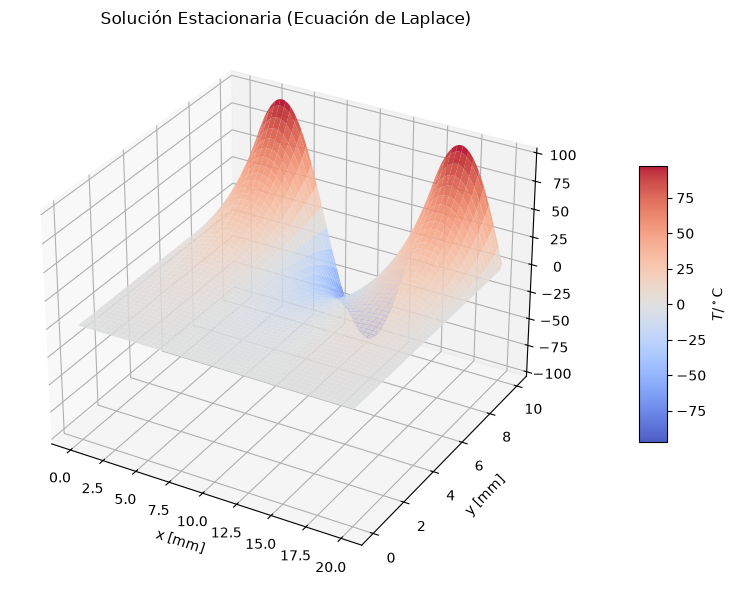

In [52]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

surf = ax.plot_surface(
    X, Y, u_estatico, cmap="coolwarm", edgecolor="none", alpha=0.9
)

ax.set_title("Solución Estacionaria (Ecuación de Laplace)", pad=2)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")


cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r"$T / ^\circ\mathrm{C}$")

plt.tight_layout()
plt.show()

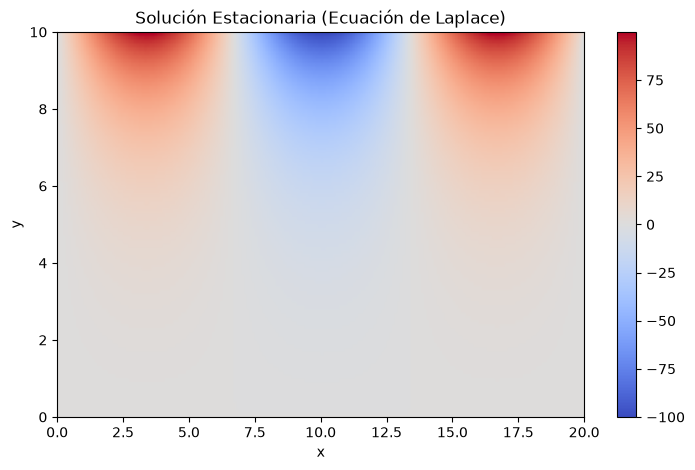

In [9]:
plt.figure(figsize=(8.5, 5))
plt.title("Solución Estacionaria (Ecuación de Laplace)")
plt.imshow(
    u_estatico.T,
    origin="lower",
    cmap="coolwarm",
    aspect="auto",
    extent=[x[0], x[-1], y[0], y[-1]],
)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

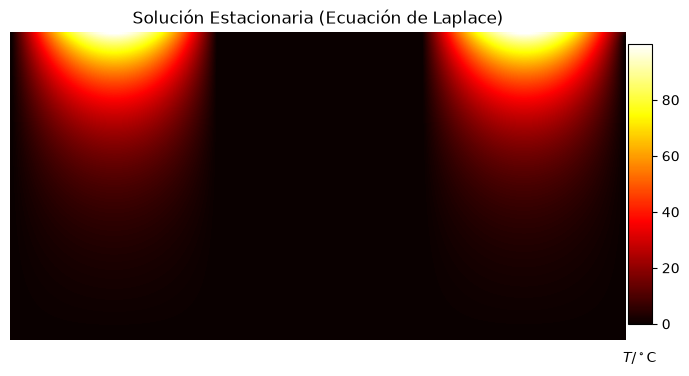

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

# Se aplica la transpuesta .T y origin='lower'
im = ax.imshow(
    u_estatico.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(U_ini),
    interpolation="bilinear",
    origin="lower",
)

ax.set_axis_off()
ax.set_title(f"Solución Estacionaria (Ecuación de Laplace)")

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

plt.show()

### <span style="color:#7EED6D; font-size: 25px"> Punto 2 </span>

**Ecuación de Difusión y Solución por Separación de Variables**

La ecuación de difusión en dos dimensiones espaciales está dada por:

$$ \nabla^2 U(x,y,t) = \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} = \frac{1}{\alpha} \frac{\partial U}{\partial t} $$

Si $t \to \infty$, se asume un estado estacionario donde $\frac{\partial U}{\partial t} = 0$, reduciéndose a la **Ecuación de Laplace**:

$$ \nabla^2 U = 0 $$

---

**Método de Separación de Variables**

Proponemos una solución del tipo $U(x,y) = X(x) Y(y)$:

$$ X''(x)Y(y) + X(x)Y''(y) = 0 \implies \frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = \lambda $$

Analizamos los tres casos para la constante de separación $\lambda$:

---

**Caso 1: $\lambda = 0$**

$$ X''(x) = 0 \quad \text{y} \quad Y''(y) = 0 $$

Las ecuaciones características dan $m^2 = 0 \implies X(x) = C_1 + C_2 x$ y $Y(y) = C_3 + C_4 x$.

Aplicando las condiciones de frontera:
* $U(0,y) = 0 \implies X(0) = 0 \implies C_1 = 0$
* $U(a,y) = 0 \implies X(a) = 0 \implies C_2 a = 0 \implies C_2 = 0 \implies X(x) = 0$

$$ U(x,y) = 0 \quad \text{(Solución Trivial)} $$

---

**Caso 2: $\lambda = \alpha^2 > 0$**

$$ X''(x) - \alpha^2 X(x) = 0 \quad \text{y} \quad Y''(y) + \alpha^2 Y(y) = 0 $$

Ecuaciones características: $m^2 - \alpha^2 = 0 \implies m = \pm\alpha$ y $m^2 + \alpha^2 = 0 \implies m = \pm i\alpha$.

$$ X(x) = A e^{\alpha x} + B e^{-\alpha x} = C_1 \cosh(\alpha x) + C_2 \sinh(\alpha x) $$
$$ Y(y) = K_1 \cos(\alpha y) + K_2 \sin(\alpha y) $$

Aplicando condiciones de frontera:
* $U(0,y) = 0 \implies C_1 \cosh(0) = 0 \implies C_1 = 0$
* $U(a,y) = 0 \implies C_2 \sinh(\alpha a) = 0 \implies \sinh(\alpha a) \neq 0, \forall a > 0 \implies C_2 = 0 \implies X(x) = 0$

$$ U(x,y) = 0 \quad \text{(Solución Trivial)} $$

---

**Caso 3: $\lambda = -\alpha^2 < 0$**

$$ X''(x) + \alpha^2 X(x) = 0 \quad \text{y} \quad Y''(y) - \alpha^2 Y(y) = 0 $$

Ecuaciones características: $m^2 + \alpha^2 = 0 \implies m = \pm i\alpha$ y $m^2 - \alpha^2 = 0 \implies m = \pm\alpha$.

$$ X(x) = K_1 \cos(\alpha x) + K_2 \sin(\alpha x) $$
$$ Y(y) = A e^{\alpha y} + B e^{-\alpha y} = C_1 \cosh(\alpha y) + C_2 \sinh(\alpha y) $$

Aplicando condiciones de frontera en $x$:
* $U(0,y) = 0 \implies X(0) = 0 \implies K_1 = 0$
* $U(a,y) = 0 \implies X(a) = 0 \implies K_2 \sin(\alpha a) = 0$

Para evitar la solución trivial exigimos $K_2 \neq 0$:

$$ \sin(\alpha a) = 0 \implies \alpha a = n\pi \implies \alpha_n = \frac{n\pi}{a} \implies X_n(x) = K_2 \sin\left(\frac{n\pi x}{a}\right) $$

Aplicando condición de frontera $U(x,0) = 0$:

$$ U(x,0) = 0 \implies Y(0) = 0 \implies C_1 = 0 \implies Y_n(y) = C_2 \sinh\left(\frac{n\pi y}{a}\right) $$

Los modos normales quedan expresados como:

$$ U_n(x,y) = A_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right) $$

---

**Determinación de Coeficientes y Solución Final**

Dada la condición superior $U(x,b) = 100 \sin\left(\frac{3\pi x}{a}\right)$:

$$ U(x,b) = \sum_{n=1}^{\infty} A_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi b}{a}\right) = 100 \sin\left(\frac{3\pi x}{a}\right) $$

Por la propiedad de ortogonalidad del seno:

$$ \int_{0}^{a} \sin\left(\frac{n\pi x}{a}\right) \sin\left(\frac{m\pi x}{a}\right) dx = \frac{a}{2} \delta_{mn} $$

Comparando coeficientes directamente para $n = 3$:

$$ A_3 \sin\left(\frac{3\pi b}{a}\right) = \frac{2}{a} \int_{0}^{a} 100 \sin\left(\frac{3\pi x}{a}\right) \sin\left(\frac{3\pi x}{a}\right) dx = \frac{100}{a} \frac{a}{2} = 100 $$

$$ A_3 = \frac{100}{\sinh\left(\frac{3\pi b}{a}\right)} $$

**Solución Particular Final**

$$ U(x,y) = 100  \sin\left(\frac{3\pi x}{a}\right) \frac{\sinh\left(\frac{3\pi y}{a}\right)}{\sinh\left(\frac{3\pi b}{a}\right)}  $$

In [53]:
# Solución Analitca
def Analitica(X,Y,a,b):
    return 100*np.sin((3*np.pi*X)/a)*((np.sinh((3*np.pi*Y)/a))/(np.sinh((3*np.pi*b)/a)))

In [54]:
x = np.linspace(0, a, nx)  
y = np.linspace(0, b, ny)  
X, Y = np.meshgrid(x, y, indexing="ij")
U_analitica = Analitica(X, Y, a, b)

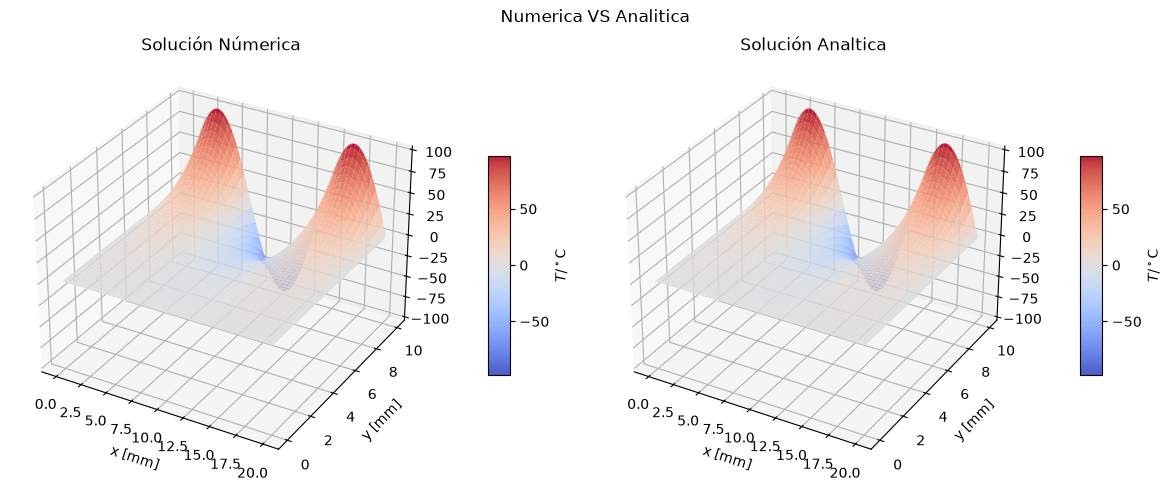

In [55]:
fig, ax = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 5))

fig.suptitle("Numerica VS Analitica")

surf = ax[1].plot_surface(
    X, Y, U_analitica, cmap="coolwarm", edgecolor="none", alpha=0.9
)
ax[1].set_title("Solución Analtica", pad=2)
ax[1].set_xlabel("x [mm]")
ax[1].set_ylabel("y [mm]")
cbar = fig.colorbar(surf, ax=ax[1], shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r"$T / ^\circ\mathrm{C}$")

surf2 = ax[0].plot_surface(
    X, Y, u_estatico, cmap="coolwarm", edgecolor="none", alpha=0.9
)

ax[0].set_title("Solución Númerica", pad=2)
ax[0].set_xlabel("x [mm]")
ax[0].set_ylabel("y [mm]")


cbar = fig.colorbar(surf, ax=ax[0], shrink=0.5, aspect=10, pad=0.1)
cbar.set_label(r"$T / ^\circ\mathrm{C}$")

plt.tight_layout()
plt.show()

In [57]:
error_mean = np.mean(np.abs(u_estatico - U_analitica)) 
error_max = np.max(np.abs(u_estatico - U_analitica))
error_relativo = (error_mean / np.max(U_analitica)) * 100
print("error maximo = ", error_max)
print("error promedio = ", error_mean)
print("error relativo = ", error_relativo)

error maximo =  4.710645070964151
error promedio =  0.31509908924587005
error relativo =  0.31510890586696677


### <span style="color:#7EED6D; font-size: 25px"> Punto 3 </span>

In [14]:
# Tiempo de Simulación [s]
t_total = 0.060
nsteps = int(t_total / dt) + 1  # el +1 es por que se quiere un arreglo de tamaño del estado inicial + los pasos de simulación

In [15]:
# Propagar la señal durante el tiempo establecido
u_actual = U_ini.copy()
for m in range(nsteps):
    u_actual = Diffusion2D(u_actual, nx, ny, dt, D, dx2, dy2)
u = u_actual

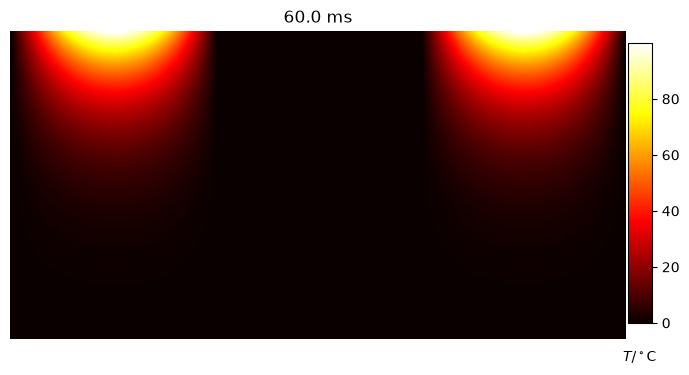

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    u.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(U_ini),
    interpolation="bilinear",
    origin="lower",
)

ax.set_axis_off()
ax.set_title(f"{t_total * 1000:.1f} ms")

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

plt.show()

In [17]:
# Propagar la señal durante el tiempo establecido
u_pasado = U_ini.copy()
u = U_ini.copy()
for m in range(nsteps):
    Diffusion2D_fast(u, u_pasado, dt, D, dx2, dy2)
    u_pasado[:, :] = u[:, :]

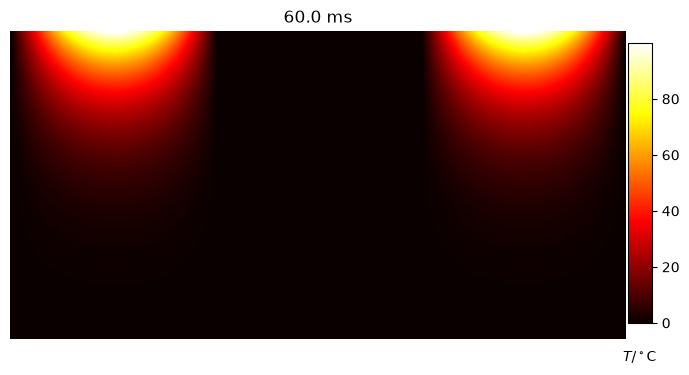

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    u.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(U_ini),
    interpolation="bilinear",
    origin="lower",
)

ax.set_axis_off()
ax.set_title(f"{t_total * 1000:.1f} ms")

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

plt.show()

In [19]:
t_total = 2
nsteps = int(t_total / dt) + 1
# Propagar la señal durante el tiempo establecido
u_pasado = U_ini.copy()
u = U_ini.copy()
for m in range(nsteps):
    Diffusion2D_fast(u, u_pasado, dt, D, dx2, dy2)
    u_pasado[:, :] = u[:, :]

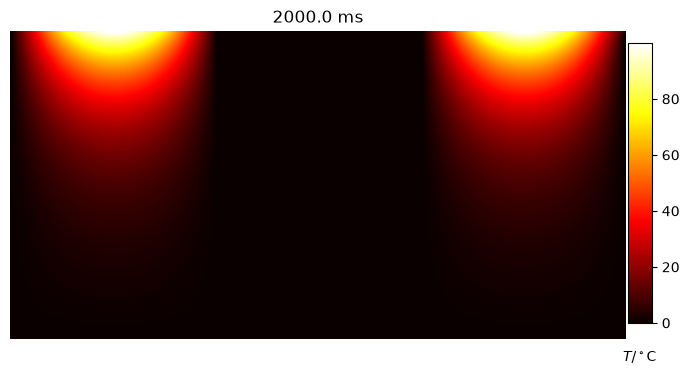

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    u.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(u),
    interpolation="bilinear",
    origin="lower",
)

ax.set_axis_off()
ax.set_title(f"{t_total * 1000:.1f} ms")

cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

plt.show()

### <span style="color:#7EED6D; font-size: 25px">Punto 4</span>

In [24]:
def update(u_matriz, im_obj, title_obj, control):
    pasos_a_ejecutar = min(subpasos, nsteps - control[0])
    for _ in range(pasos_a_ejecutar):
        Diffusion2D_fast(u_matriz, u_matriz, dt, D, dx2, dy2)
        control[0] += 1
    tiempo_ms = control[0] * dt * 1000
    im_obj.set_data(u_matriz.T)
    title_obj.set_text(f"{tiempo_ms:.2f} ms")
    return [im_obj, title_obj]

In [25]:
t_total = 0.05
nsteps = int(t_total / dt)
n_frames = 100
# Subpasos por cuadro
subpasos = max(1, nsteps // n_frames)
# Reajustar n_frames para cubrir todo nsteps
n_frames = int(np.ceil(nsteps / subpasos))

In [26]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
u_anim = U_ini.copy()

# Imagen Inicial
im = ax.imshow(
    u_anim.T,
    cmap="hot",
    vmin=0,
    vmax=np.max(U_ini),
    interpolation="bilinear",
    origin="lower",
    aspect="auto",
)

ax.set_axis_off()
title_text = ax.set_title("0.00 ms", pad=6)

# Barra de color
cbar_ax = fig.add_axes([0.84, 0.08, 0.03, 0.80])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar_ax.set_xlabel(r"$T / ^\circ\mathrm{C}$", labelpad=8)

fig.subplots_adjust(left=0.01, right=0.82, top=0.88, bottom=0.08)

# 2. Generar fotogramas en memoria recortando todo el espacio blanco sobrante
frames = []
pasos_control = [0]

for i in range(n_frames):
    update(u_anim, im, title_text, pasos_control) 
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.02, dpi=120)
    buf.seek(0)
    img = Image.open(buf)
    frames.append(img.copy())

plt.close(fig)  

# 3. Guardar el GIF final ensamblado frame por frame
frames[0].save(
    "temperatura_difusion.gif",
    save_all=True,
    append_images=frames[1:],
    duration=50,  # Intervalo en ms entre cuadros para 20 FPS
    loop=0,  # 0 significa bucle infinito
)

<span style="color:#bf0f2a; font-size: 25px">Para reproducir usar [!nbviewer](https://nbviewer.org/)</span>

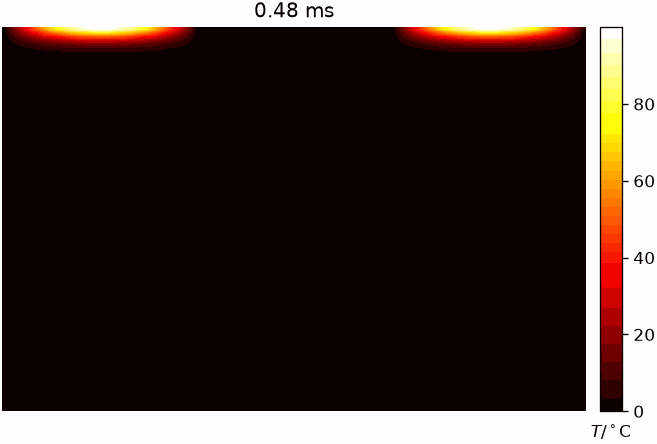

In [27]:
display(DisplayImage(filename="temperatura_difusion.gif"))